# 01_collection_phase1_v3 — DART 사업보고서 정밀 수집 (v2 fix + 정밀 세분화)

> **작성자**: 이동원 · **작성일**: 2026-05-16 · **버전**: v3
> **이전 버전**: `01_collection_phase1_v2.ipynb` (viewer 0/5 일치 — 감사보고서 노이즈 추출)
> **보고서**: `members/이동원/reports/01_collection/01_collection_phase1_v3_보고서.md`

## 본 노트북이 처리하는 가이드 단계 (가이드 02 line 153~158)

| 가이드 line | 내용 | 본 노트북 셀 |
|---|---|---|
| 1 (line 153) | stock_code → corp_code | Step 3 |
| 2 (line 154) | corp_code → rcept_no | Step 4 (+ 정정공시 이력 — 세분화 축 B) |
| 3 (line 155) | document.xml zip 저장 | Step 5 (+ type 판별, **Fix #0** + 세분화 축 A) |
| 4 (line 156) | XML → 텍스트 추출 | Step 6 (**Fix #2** lxml itertext) |
| 5 (line 157) | II/IV/VI 섹션 발췌 | Step 7 (**Fix #1·#3** + 세분화 축 C) |
| 6 (line 158) | ESG passage 추출 | Step 8 |

가이드 line 159-166 (7-14번: 형태소·불용어·TF-IDF·fastText·회귀)은 본 노트북 범위 외 — `02_preprocessing_v1.ipynb` 이후.

## v3 분석 단위 (가이드 line 21-35, 117)

- 식별자: **stock_code × fiscal_year** (회사명 join 금지 — 가이드 line 35, 위반금지 #7)
- esg_year = fiscal_year + 1 (가이드 line 37-38)
- 모집단: 최대 127 stock × 3 fiscal_year = **381 firm-year** (가이드 line 117)
- 파일럿: stock_code=005930 (삼성전자), fiscal_year=2024, esg_year=2025


---

## Step 0 · 가이드 매핑·위반금지 8항목 사전 점검

본 노트북 실행 전, 가이드 02의 위반금지 8항목을 사전 명시. 각 Step에서 해당 항목을 어떻게 준수하는지 추적.

| # | 위반금지 | 가이드 라인 | 본 노트북 적용 위치 |
|---|---|---|---|
| 1 | 실패 행을 가짜 0으로 채우기 ❌ | line 172, 286 | Step 5 `FAIL_NO_BUSINESS_REPORT` · Step 10 status 세분화 |
| 2 | viewer 우회 ❌ | line 67, 94 | Step 5 document.xml만 사용 · Step 9 viewer 검증 |
| 3 | MCP/LLM 추출 결과 그대로 신뢰 ❌ | line 94 | Step 9 viewer 5 sample 수동 검증 |
| 4 | API key 출력 노출 ❌ | line 216-222 | Step 1 `mask_key()` |
| 5 | raw 미보존 ❌ | line 155 | Step 5 `data/raw/*.zip` 보존 |
| 6 | 진단 부재 ❌ | line 143-146, 170-172 | Step 5·6·7 진단 출력 |
| 7 | silent 오매칭 (회사명 join) ❌ | line 35 | Step 2 stock_code 기준 |
| 8 | 평가 기준 부재 ❌ | line 145 | Step 9 viewer 5/5 기준 + Step 11 self-check |

위반금지 8항목 외 추가 준수:
- **가이드 line 18**: target = 사업보고서 II/IV/VI → Step 5 type 판별 + Step 7 헤딩 매칭
- **가이드 line 69**: 정정공시 rcept_no 기록 → Step 4 `last_reprt_at=Y` + 세분화 축 B (`correction_log.csv`)


---

## Step 1 · 환경 셋업 + API key 안전 (가이드 line 216-222)

**가이드 매핑**: line 216-222 (.env + os.getenv 패턴)
**위반금지**: #4 (API key 출력 노출 ❌) — `mask_key()` 헬퍼로 길이만 노출

**v1·v2와 차이**: `find_project_root()` 그대로 사용 (v2 Fix #1). 추가로 v3에서 lxml import.


In [2]:
# Colab 사용자만 주석 해제
# !pip install python-dotenv pandas requests lxml tqdm matplotlib pyarrow

import os, sys, re, json, time, zipfile, warnings
from io import BytesIO
from pathlib import Path
from datetime import datetime

import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from dotenv import load_dotenv

# v3 신규: lxml (Fix #2 — strip_tags 무손실)
try:
    from lxml import etree
    LXML_AVAILABLE = True
except ImportError:
    LXML_AVAILABLE = False
    print("⚠️ lxml 미설치 — 정규식 fallback만 사용. `pip install lxml` 권장.")

# 한글 폰트 + 음수 부호
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        matplotlib.rcParams['font.family'] = f
        break
    except Exception:
        pass

warnings.filterwarnings('ignore')


def find_project_root() -> Path:
    """v2 Fix #1 — cwd부터 상위 경로에서 anchor 파일 탐색."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'company_master.csv').exists():
            return candidate
    raise FileNotFoundError(
        "project root not found — `data/company_master.csv` 찾을 수 없음"
    )


def mask_key(key: str) -> str:
    """위반금지 #4 — API key 출력 시 길이·앞4자리만."""
    if not key:
        return '(empty)'
    return f"{key[:4]}...len={len(key)}"


ROOT = find_project_root()
print(f"📍 ROOT: {ROOT}")

load_dotenv(ROOT / '.env')

# ⚠️ 가이드 02 line 216-222 예시는 OPENDART_API_KEY 이지만,
#    이동원 .env는 `API_KEY` 이름으로 운영 중 (v1→v2 학습).
#    키 이름을 가정하지 말고 후보 리스트로 견고하게 시도.
KEY_CANDIDATES = ['OPENDART_API_KEY', 'API_KEY', 'DART_API_KEY']
API_KEY = next((os.getenv(k) for k in KEY_CANDIDATES if os.getenv(k)), None)
assert API_KEY, f"❌ {KEY_CANDIDATES} 중 어느 것도 .env에 없습니다. 파일 안 키 이름을 확인하세요."
print(f"✅ API key 로드 완료 ({mask_key(API_KEY)})")

# 출력 디렉토리
DIR_RAW = ROOT / 'data' / 'raw'
DIR_INTERIM = ROOT / 'data' / 'interim'
DIR_CACHE = ROOT / 'data' / 'cache'
DIR_LOGS = ROOT / 'logs'
for d in [DIR_RAW, DIR_INTERIM, DIR_CACHE, DIR_LOGS]:
    d.mkdir(parents=True, exist_ok=True)
print("\n📁 출력 디렉토리 준비 완료 (raw·interim·cache → gitignore, logs → git)")
print(f"   lxml 사용 가능: {LXML_AVAILABLE}")


📍 ROOT: c:\Users\kik32\workspace\unstructured-data-processing-final-project
✅ API key 로드 완료 (0e1e...len=40)

📁 출력 디렉토리 준비 완료 (raw·interim·cache → gitignore, logs → git)
   lxml 사용 가능: True


---

## Step 2 · 파일럿 대상 설정 + company_master 검증

**가이드 매핑**: line 21-35 (식별자), line 35 (silent 오매칭 금지), line 38 (esg_year = fiscal+1), line 117 (381)
**위반금지**: #7 (silent 오매칭) — `stock_code` 기준 행 선택


In [3]:
# 파일럿 변수
PILOT_STOCK = '005930'  # 삼성전자
PILOT_FISCAL = 2024
PILOT_ESG_YEAR = PILOT_FISCAL + 1  # 가이드 line 38

cm = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})
n_rows = len(cm)
n_unique_stock = cm['stock_code'].nunique()
fiscal_years = sorted(cm['fiscal_year'].unique().tolist())

print("📊 company_master 검증 (가이드 line 117)")
print(f"   총 행 수:     {n_rows} (예상 381)")
print(f"   unique stock: {n_unique_stock} (예상 127)")
print(f"   fiscal_year:  {fiscal_years} (예상 [2022, 2023, 2024])")

# stock_code 기준 행 선택 (위반금지 #7 silent 오매칭 방지)
pilot_rows = cm[(cm['stock_code'] == PILOT_STOCK) & (cm['fiscal_year'] == PILOT_FISCAL)]
assert len(pilot_rows) == 1, f"파일럿 행 수가 1이 아님: {len(pilot_rows)}"
pilot_row = pilot_rows.iloc[0]

print(f"\n🎯 파일럿 대상")
print(f"   stock_code:  {PILOT_STOCK}")
print(f"   fiscal_year: {PILOT_FISCAL}")
print(f"   esg_year:    {PILOT_ESG_YEAR}")
pilot_row.to_frame()


📊 company_master 검증 (가이드 line 117)
   총 행 수:     381 (예상 381)
   unique stock: 127 (예상 127)
   fiscal_year:  [2022, 2023, 2024] (예상 [2022, 2023, 2024])

🎯 파일럿 대상
   stock_code:  005930
   fiscal_year: 2024
   esg_year:    2025


,2
company_name,삼성전자
corp_code,NaN
stock_code,005930
industry,전기전자
fiscal_year,2024
report_code,11011
rcept_no,NaN
esg_source,한국ESG기준원
esg_grade,A
e_grade,B+


---

## Step 3 · stock_code → corp_code (가이드 line 153)

**가이드 매핑**: line 153 (1. stock → corp), line 28 (corpCode.xml)
**v1·v2와 차이**: 없음 — corp_code_map.parquet 캐시 그대로 재사용


In [4]:
def fetch_corp_code_map(api_key: str, cache_dir: Path) -> pd.DataFrame:
    """corpCode.xml 1회 다운로드 → DataFrame → parquet 캐시."""
    cache_path = cache_dir / 'corp_code_map.parquet'
    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        print(f"📦 캐시에서 로드: {cache_path.name} ({len(df):,}건)")
        return df
    # cache miss — 다운로드
    res = requests.get(
        "https://opendart.fss.or.kr/api/corpCode.xml",
        params={'crtfc_key': api_key},
        timeout=30,
    )
    res.raise_for_status()
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_bytes = zf.read(zf.namelist()[0])
    if LXML_AVAILABLE:
        root = etree.fromstring(xml_bytes)
        rows = []
        for el in root.findall('list'):
            rows.append({
                'corp_code': (el.findtext('corp_code') or '').strip(),
                'corp_name': (el.findtext('corp_name') or '').strip(),
                'stock_code': (el.findtext('stock_code') or '').strip(),
            })
        df = pd.DataFrame(rows)
    else:
        # fallback — 정규식
        text = xml_bytes.decode('utf-8', errors='ignore')
        df = pd.DataFrame({'raw': [text[:100]]})
        raise RuntimeError("lxml 없이 corpCode 파싱 미지원")
    df = df[df['stock_code'].str.len() == 6]  # 상장사만
    df.to_parquet(cache_path, index=False)
    print(f"📥 새로 다운로드 + 캐시 저장: {cache_path.name} ({len(df):,}건)")
    return df


corp_map = fetch_corp_code_map(API_KEY, DIR_CACHE)
match = corp_map[corp_map['stock_code'] == PILOT_STOCK]
assert len(match) == 1, f"corp_code 매칭 실패 — stock={PILOT_STOCK}, 매칭 수={len(match)}"
PILOT_CORP = match.iloc[0]['corp_code']
print(f"\n✅ stock_code={PILOT_STOCK} → corp_code={PILOT_CORP} ({match.iloc[0]['corp_name']})")


📦 캐시에서 로드: corp_code_map.parquet (3,965건)

✅ stock_code=005930 → corp_code=00126380 (삼성전자)


---

## Step 4 · corp_code → rcept_no + 정정공시 이력 추적 (가이드 line 154, 69)

**가이드 매핑**: line 154 (2. corp → rcept), line 69 (정정공시 rcept_no 기록)
**v3 세분화 축 B**: 같은 fiscal_year에 다른 rcept_no가 있었다면 `logs/correction_log.csv`에 기록


In [5]:
def find_rcept_no_v3(api_key: str, corp_code: str, fiscal_year: int) -> dict:
    """가이드 line 154 + line 69 — 정정공시 이력도 함께 수집.

    Returns:
        dict with keys:
            - selected: dict (rcept_no, rcept_dt, report_nm, viewer_url) — last_reprt_at=Y 결과
            - all_candidates: list[dict] — 정정 이력 포함 모든 사업보고서
    """
    # 1) last_reprt_at=Y로 최종 보고서
    params_final = {
        'crtfc_key': api_key,
        'corp_code': corp_code,
        'bgn_de': f'{fiscal_year + 1}0101',
        'end_de': f'{fiscal_year + 1}1231',
        'pblntf_detail_ty': 'A001',
        'last_reprt_at': 'Y',
        'page_count': '100',
    }
    res = requests.get(
        'https://opendart.fss.or.kr/api/list.json',
        params=params_final, timeout=20,
    )
    res.raise_for_status()
    rows = res.json().get('list', [])
    target_label = f'({fiscal_year}.12)'
    finals = [r for r in rows if '사업보고서' in r.get('report_nm', '') and target_label in r.get('report_nm', '')]
    if not finals:
        raise RuntimeError(f"FAIL_LIST — 사업보고서 {target_label} 없음")
    selected_row = finals[0]
    selected = {
        'rcept_no': selected_row['rcept_no'],
        'rcept_dt': selected_row['rcept_dt'],
        'report_nm': selected_row['report_nm'],
        'viewer_url': f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={selected_row['rcept_no']}",
    }

    # 2) 정정공시 이력 (last_reprt_at=N으로 모두)
    params_all = {**params_final, 'last_reprt_at': 'N'}
    res2 = requests.get(
        'https://opendart.fss.or.kr/api/list.json',
        params=params_all, timeout=20,
    )
    all_candidates = []
    if res2.status_code == 200:
        rows2 = res2.json().get('list', [])
        for r in rows2:
            if '사업보고서' in r.get('report_nm', '') and target_label in r.get('report_nm', ''):
                all_candidates.append({
                    'rcept_no': r['rcept_no'],
                    'rcept_dt': r['rcept_dt'],
                    'report_nm': r['report_nm'],
                })
    return {'selected': selected, 'all_candidates': all_candidates}


result_step4 = find_rcept_no_v3(API_KEY, PILOT_CORP, PILOT_FISCAL)
PILOT_RCEPT = result_step4['selected']['rcept_no']
VIEWER_URL = result_step4['selected']['viewer_url']

print(f"✅ rcept_no 조회 성공 (가이드 line 154)")
print(f"   rcept_no:    {PILOT_RCEPT}")
print(f"   rcept_dt:    {result_step4['selected']['rcept_dt']}")
print(f"   report_nm:   {result_step4['selected']['report_nm']}")
print(f"   viewer URL:  {VIEWER_URL}")

# 정정공시 이력 (세분화 축 B + 가이드 line 69)
n_corrections = max(0, len(result_step4['all_candidates']) - 1)
print(f"\n📜 정정공시 이력 (가이드 line 69, 세분화 축 B)")
print(f"   같은 fiscal_year={PILOT_FISCAL} 후보 수: {len(result_step4['all_candidates'])}")
print(f"   정정 이력 추정: {n_corrections}건")
if n_corrections > 0:
    print("   후보 목록 (rcept_dt 순):")
    for c in sorted(result_step4['all_candidates'], key=lambda x: x['rcept_dt']):
        marker = " ⭐(selected)" if c['rcept_no'] == PILOT_RCEPT else ""
        print(f"      - {c['rcept_dt']} | {c['rcept_no']} | {c['report_nm']}{marker}")
else:
    print("   (단일 보고서 — 정정 없음)")


✅ rcept_no 조회 성공 (가이드 line 154)
   rcept_no:    20250311001085
   rcept_dt:    20250311
   report_nm:   사업보고서 (2024.12)
   viewer URL:  https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085

📜 정정공시 이력 (가이드 line 69, 세분화 축 B)
   같은 fiscal_year=2024 후보 수: 1
   정정 이력 추정: 0건
   (단일 보고서 — 정정 없음)


---

## Step 5 · document.xml zip 다운로드 + **type 판별** (Fix #0 + 세분화 축 A)

**가이드 매핑**: line 155 (3. document.xml zip 저장) + line 18 (target=사업보고서)
**위반금지**: #5 (raw 미보존) — zip은 그대로 `data/raw/`에 저장 / #2 (viewer 우회) — document.xml만 사용 / #1 (가짜 0) — 사업보고서 없으면 명시적 실패

### 🚨 v3 핵심 신규 — Fix #0
zip 안 모든 XML을 `<DOCUMENT-NAME>` 으로 type 판별하여:
- **primary = 사업보고서 본문** (ESG corpus, 가이드 line 18)
- **secondary = 연결감사보고서, 감사보고서** (별도 라벨로 보존 — 세분화 축 A, 02 전처리에서 비교 분석 가능)

가이드 line 250-261 예시 코드 `zf.namelist()[0]`의 한계 보강 — 가이드 의도(line 18) 충실 구현.


In [6]:
DOC_TYPE_PATTERN = re.compile(
    r'<DOCUMENT-NAME[^>]*>([^<]+)</DOCUMENT-NAME>', re.UNICODE
)


def download_document_xml_v3(api_key: str, rcept_no: str, stock_code: str,
                              fiscal_year: int, raw_dir: Path) -> dict:
    """가이드 line 155 + Fix #0 — zip 보존 + DOCUMENT-NAME type 판별.

    Returns:
        dict with:
            - zip_path: Path (raw zip 위치)
            - sources: dict[type, list[(filename, xml_text)]]
            - primary: tuple (filename, xml_text, doc_type) or None
            - n_xml_files: int
    """
    zip_path = raw_dir / f'{stock_code}_{fiscal_year}_disclosure.zip'

    # idempotent: 캐시 hit 시 재다운로드 X (위반금지 #5 raw 보존)
    if zip_path.exists() and zip_path.stat().st_size > 1024:
        zip_bytes = zip_path.read_bytes()
        print(f"📦 캐시에서 로드: {zip_path.name} ({zip_path.stat().st_size / 1024:.1f} KB)")
    else:
        res = requests.get(
            'https://opendart.fss.or.kr/api/document.xml',
            params={'crtfc_key': api_key, 'rcept_no': rcept_no},
            timeout=60,
        )
        res.raise_for_status()
        zip_bytes = res.content
        zip_path.write_bytes(zip_bytes)
        print(f"📥 새 다운로드 + 저장: {zip_path.name} ({len(zip_bytes) / 1024:.1f} KB)")

    # type 판별 (Fix #0)
    sources = {'사업보고서': [], '연결감사보고서': [], '감사보고서': [], 'unknown': []}
    with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
        n_files = len(zf.namelist())
        print(f"\n📄 zip 안 XML 파일 {n_files}개 (Fix #0 type 판별)")
        for name in zf.namelist():
            xml_text = zf.read(name).decode('utf-8', errors='ignore')
            m = DOC_TYPE_PATTERN.search(xml_text)
            doc_type = m.group(1).strip() if m else 'unknown'
            normalized = doc_type if doc_type in sources else 'unknown'
            sources[normalized].append((name, xml_text, doc_type))
            print(f"   - {name}: {len(xml_text):>10,}자 | DOCUMENT-NAME: {doc_type}")

    # primary 선택 — 사업보고서 본문, 가장 큰 파일
    primary = None
    if sources['사업보고서']:
        primary = max(sources['사업보고서'], key=lambda x: len(x[1]))
        print(f"\n⭐ primary 선택 (가이드 line 18 target):")
        print(f"   {primary[0]} ({len(primary[1]):,}자, DOCUMENT-NAME={primary[2]})")
    elif sources['unknown']:
        # fallback — unknown 중 가장 큰 파일을 사업보고서로 추정
        primary = max(sources['unknown'], key=lambda x: len(x[1]))
        print(f"\n⚠️ '사업보고서' DOCUMENT-NAME 없음 — unknown 중 가장 큰 파일 사용:")
        print(f"   {primary[0]} ({len(primary[1]):,}자, DOCUMENT-NAME={primary[2]})")
    else:
        # 위반금지 #1 — 가짜 0 금지, 명시적 실패
        raise RuntimeError("FAIL_NO_BUSINESS_REPORT — zip에 사업보고서 파일 없음")

    # secondary 정리
    print(f"\n📚 보조 보고서 (세분화 축 A — 별도 보존):")
    for k in ['연결감사보고서', '감사보고서']:
        if sources[k]:
            for fn, xt, _ in sources[k]:
                print(f"   [{k}] {fn} ({len(xt):,}자)")
        else:
            print(f"   [{k}] (없음)")

    return {
        'zip_path': zip_path,
        'sources': sources,
        'primary': primary,
        'n_xml_files': n_files,
    }


result_step5 = download_document_xml_v3(API_KEY, PILOT_RCEPT, PILOT_STOCK, PILOT_FISCAL, DIR_RAW)
PRIMARY_NAME, PRIMARY_XML, PRIMARY_TYPE = result_step5['primary']
print(f"\n📑 primary XML 길이: {len(PRIMARY_XML):,}자 (다음 Step에서 lxml로 텍스트 추출)")


📦 캐시에서 로드: 005930_2024_disclosure.zip (660.2 KB)

📄 zip 안 XML 파일 3개 (Fix #0 type 판별)
   - 20250311001085_00761.xml:    623,804자 | DOCUMENT-NAME: 연결감사보고서
   - 20250311001085_00760.xml:    531,069자 | DOCUMENT-NAME: 감사보고서
   - 20250311001085.xml:  5,780,877자 | DOCUMENT-NAME: 사업보고서

⭐ primary 선택 (가이드 line 18 target):
   20250311001085.xml (5,780,877자, DOCUMENT-NAME=사업보고서)

📚 보조 보고서 (세분화 축 A — 별도 보존):
   [연결감사보고서] 20250311001085_00761.xml (623,804자)
   [감사보고서] 20250311001085_00760.xml (531,069자)

📑 primary XML 길이: 5,780,877자 (다음 Step에서 lxml로 텍스트 추출)


---

## Step 5+ · 보조 보고서 별도 보존 (세분화 축 A)

연결감사보고서·감사보고서를 raw 텍스트로 별도 json에 저장. 02 전처리 단계에서 primary vs secondary 비교 분석 가능.


In [7]:
def save_aux_sources(sources: dict, stock_code: str, fiscal_year: int,
                      interim_dir: Path) -> dict:
    """보조 보고서를 type별 json으로 저장 (세분화 축 A)."""
    saved = {}
    name_map = {
        '연결감사보고서': 'aux_audit_consolidated',
        '감사보고서': 'aux_audit_separate',
    }
    for doc_type, suffix in name_map.items():
        items = sources.get(doc_type, [])
        if not items:
            saved[doc_type] = None
            continue
        out = {
            'doc_type': doc_type,
            'stock_code': stock_code,
            'fiscal_year': fiscal_year,
            'files': [
                {'filename': fn, 'doc_name_in_xml': dt, 'xml_text_length': len(xt),
                 'xml_text': xt}
                for fn, xt, dt in items
            ],
        }
        path = interim_dir / f'{stock_code}_{fiscal_year}_{suffix}.json'
        path.write_text(json.dumps(out, ensure_ascii=False), encoding='utf-8')
        saved[doc_type] = path
        print(f"💾 [{doc_type}] {path.name} ({path.stat().st_size / 1024:.1f} KB)")
    return saved


aux_saved = save_aux_sources(
    result_step5['sources'], PILOT_STOCK, PILOT_FISCAL, DIR_INTERIM
)


💾 [연결감사보고서] 005930_2024_aux_audit_consolidated.json (763.7 KB)
💾 [감사보고서] 005930_2024_aux_audit_separate.json (648.7 KB)


---

## Step 6 · XML → 텍스트 추출 (가이드 line 156, **Fix #2** lxml itertext)

**가이드 매핑**: line 156 (4. XML에서 텍스트 추출)
**Fix #2**: lxml `etree.fromstring` + `root.itertext()` → 무손실 추출. 실패 시 정규식 fallback.
**진단**: XML 길이 / 텍스트 길이 / 압축률을 출력 (위반금지 #6 — 진단 부재 금지).


In [8]:
def strip_tags_v3(xml_text: str) -> tuple[str, dict]:
    """Fix #2 — lxml itertext 무손실 추출 + 단계별 진단."""
    diag = {'xml_length': len(xml_text), 'method': None, 'error': None}

    text = ''
    if LXML_AVAILABLE:
        try:
            parser = etree.XMLParser(recover=True, huge_tree=True)
            root = etree.fromstring(xml_text.encode('utf-8'), parser=parser)
            if root is not None:
                text = ' '.join(t for t in root.itertext() if t)
                diag['method'] = 'lxml_itertext'
        except Exception as e:
            diag['error'] = f'lxml_failed: {e}'
            text = ''

    if not text:
        # fallback — 정규식
        text = re.sub(r'<[^>]+>', ' ', xml_text)
        diag['method'] = diag['method'] or 'regex_fallback'

    text = re.sub(r'\s+', ' ', text).strip()
    diag['text_length'] = len(text)
    diag['compression_rate'] = (diag['text_length'] / diag['xml_length']) if diag['xml_length'] else 0
    return text, diag


PRIMARY_TEXT, diag6 = strip_tags_v3(PRIMARY_XML)

print(f"📝 strip_tags v3 진단 (Fix #2, 위반금지 #6 진단 출력)")
print(f"   method:           {diag6['method']}")
print(f"   XML 길이:         {diag6['xml_length']:>12,}자")
print(f"   추출 텍스트 길이:  {diag6['text_length']:>12,}자")
print(f"   압축률:           {diag6['compression_rate']*100:.2f}%  (목표 ≥ 20%)")
if diag6['error']:
    print(f"   ⚠️ lxml 에러: {diag6['error']}")

print(f"\n   추출 텍스트 앞 500자:")
print(f"   {PRIMARY_TEXT[:500]!r}")
print(f"\n   추출 텍스트 뒤 500자:")
print(f"   {PRIMARY_TEXT[-500:]!r}")

# 검증 기준 (Step 9 / Step 11 self-check 입력)
COMPRESSION_OK = diag6['compression_rate'] >= 0.20
TEXT_LEN_OK = diag6['text_length'] >= 1_150_000
print(f"\n📊 검증")
print(f"   압축률 ≥ 20%: {'✅' if COMPRESSION_OK else '⚠️'}")
print(f"   텍스트 ≥ 1.15M자: {'✅' if TEXT_LEN_OK else '⚠️'}")


📝 strip_tags v3 진단 (Fix #2, 위반금지 #6 진단 출력)
   method:           lxml_itertext
   XML 길이:            5,780,877자
   추출 텍스트 길이:       658,847자
   압축률:           11.40%  (목표 ≥ 20%)

   추출 텍스트 앞 500자:
   '사업보고서 6.0 삼성전자주식회사 C A Y 130111-0006246 사 업 보 고 서 (제 56 기) 사업연도 2024년 01월 01일 부터 2024년 12월 31일 까지 금융위원회 한국거래소 귀중 2025년 3월 11일 제출대상법인 유형 : 주권상장법인 면제사유발생 : 해당사항 없음 회 사 명 : 삼성전자주식회사 대 표 이 사 : 한 종 희 본 점 소 재 지 : 경기도 수원시 영통구 삼성로 129(매탄동) (전 화) 031-200-1114 (홈페이지) http://www.samsung.com/sec 작 성 책 임 자 : (직 책) 재경팀장 (성 명) 김 동 욱 (전 화) 031-277-7218 목 차 【 대표이사 등의 확인 】 대표이사 확인서.jpg 대표이사 확인서 I. 회사의 개요 1. 회사의 개요 가. 회사의 법적ㆍ상업적 명칭 당사의 명칭은 삼성전자주식회사이고 영문명은 Samsung Electronics Co., Ltd. 입니다. 나. 설립일자 당사는 1969년 1월 13일'

   추출 텍스트 뒤 500자:
   '개발로, 비정형 Display의 영역별 균일특성 확보 - 대면적 비정형 OCTA 기술 개발 Surface Pro 10 개발(2024.05.) □ 13" WQ+ (2,880x1,920, 3:2) - 30Hz 저주파 구동 노트북 OLED 최초 적용 (30~120Hz 가변주사율)으로 低소비전력 구현 Galaxy Z Fold6용폴더블 OLED개발(2024.07.) □ 7.61" (2,160x1,856) 폴더블用 Display - 광효율 및 시인성 개선 新패널 구조/재료 적용으로 低소비전력 구현,

---

## Step 7 · II/IV/VI 섹션 발췌 (가이드 line 157, **Fix #1 + #3** + 세분화 축 C)

**가이드 매핑**: line 157 (5. II/IV/VI 발췌) + line 18 (target)
**Fix #1**: 한국어 헤딩 변형 6~8 패턴 (`II.` · `Ⅱ` · `2.` · `제2장` · `Part II` · 핵심 키워드 fallback)
**Fix #3**: 모든 헤딩 후보 pos 정렬 → 본문 위치(≥ 5,000자)만 사용 (목차 제외) + 다음 헤딩 없으면 200,000자 cap (VI 과추출 방지)
**세분화 축 C**: 매칭 결과를 `logs/section_match_v3.csv`에 회사별로 기록


In [9]:
# 헤딩 패턴 (Fix #1) — 한국어 변형 6~8개씩
HEADING_PATTERNS_V3 = {
    'II':  [
        r'(?:II|Ⅱ|2)\s*\.\s*사업의\s*내용',
        r'(?:II|Ⅱ|2)\s*[\.)\]]\s*사업의\s*내용',
        r'제\s*2\s*장\s*[\.\s]*사업의\s*내용',
        r'Part\s*II\s*[\.\s]*사업의\s*내용',
        r'사업의\s*내용\s*및\s*관련\s*위험',
        r'사업의\s*내용',
    ],
    'III': [
        r'(?:III|Ⅲ|3)\s*\.\s*재무에\s*관한\s*사항',
        r'제\s*3\s*장\s*[\.\s]*재무에\s*관한\s*사항',
        r'재무에\s*관한\s*사항',
    ],
    'IV':  [
        r'(?:IV|Ⅳ|4)\s*\.\s*이사의\s*경영진단',
        r'(?:IV|Ⅳ|4)\s*\.\s*감사인',
        r'제\s*4\s*장\s*[\.\s]*이사',
        r'이사의\s*경영진단\s*및\s*분석의견',
        r'감사인의\s*감사의견\s*등',
    ],
    'V':   [
        r'(?:V|Ⅴ|5)\s*\.\s*감사인',
        r'(?:V|Ⅴ|5)\s*\.\s*임원',
        r'제\s*5\s*장',
        r'감사인의\s*감사의견',
        r'임원\s*및\s*직원\s*등에\s*관한\s*사항',
    ],
    'VI':  [
        r'(?:VI|Ⅵ|6)\s*\.\s*이사회',
        r'(?:VI|Ⅵ|6)\s*\.\s*주주',
        r'제\s*6\s*장',
        r'이사회\s*등\s*회사의\s*기관에\s*관한\s*사항',
        r'주주에\s*관한\s*사항',
    ],
    'VII': [
        r'(?:VII|Ⅶ|7)\s*\.\s*주주',
        r'(?:VII|Ⅶ|7)\s*\.\s*거래처',
        r'(?:VII|Ⅶ|7)\s*\.\s*그\s*밖',
        r'제\s*7\s*장',
        r'그\s*밖에\s*투자자\s*보호를\s*위하여',
        r'계열회사\s*등에\s*관한\s*사항',
    ],
}


def find_all_heading_positions(text: str, patterns: list[str],
                                 min_pos: int = 5000) -> list[tuple[int, int]]:
    """본문(>= min_pos)에서 모든 헤딩 후보 위치 수집. (pos, pattern_idx) list."""
    candidates = []
    for idx, pat in enumerate(patterns):
        for m in re.finditer(pat, text):
            if m.start() >= min_pos:
                candidates.append((m.start(), idx))
    return sorted(candidates)


def extract_sections_v3(text: str, min_pos: int = 5000,
                         max_section_len: int = 200_000) -> tuple[dict, list]:
    """Fix #1 + #3 — 본문 위치만 사용 + 다음 헤딩 없으면 cap.

    Returns:
        sections: dict[label, str]
        match_log: list[dict] (logs/section_match_v3.csv 입력용)
    """
    sections = {}
    match_log = []
    section_starts = {}  # label -> (pos, pattern_idx)

    # 1) 각 섹션의 시작 위치 식별
    print("🔍 헤딩 검색 결과 (Fix #1, 본문 위치 >= 5,000자만)")
    for label, patterns in HEADING_PATTERNS_V3.items():
        cands = find_all_heading_positions(text, patterns, min_pos=min_pos)
        if cands:
            pos, pat_idx = cands[0]  # 가장 먼저 등장 (본문 첫 매칭)
            section_starts[label] = (pos, pat_idx)
            print(f"   ✅ {label}: pos={pos:>9,} | pattern[{pat_idx}]: {patterns[pat_idx][:50]}")
            match_log.append({'section': label, 'matched': True, 'pos': pos,
                              'pattern_idx': pat_idx, 'pattern': patterns[pat_idx][:60]})
        else:
            print(f"   ❌ {label}: 매칭 실패 (패턴 {len(patterns)}개 모두)")
            match_log.append({'section': label, 'matched': False, 'pos': None,
                              'pattern_idx': None, 'pattern': None})

    # 2) 정렬된 위치 기반 슬라이싱
    order = ['II', 'III', 'IV', 'V', 'VI', 'VII']
    text_len = len(text)
    for i, label in enumerate(order):
        if label not in section_starts:
            continue
        start = section_starts[label][0]
        # 다음 섹션 시작점 찾기 (Fix #3 — VII 없으면 cap)
        next_start = None
        for next_label in order[i+1:]:
            if next_label in section_starts:
                next_start = section_starts[next_label][0]
                break
        if next_start is None:
            # 마지막 섹션 — cap 적용
            end = min(start + max_section_len, text_len)
        else:
            end = next_start
        sections[label] = text[start:end].strip()

    # 3) 진단 출력
    print(f"\n📑 추출된 섹션 (II/IV/VI 우선):")
    for label in ['II', 'III', 'IV', 'V', 'VI', 'VII']:
        if label in sections:
            mark = '⭐' if label in ('II', 'IV', 'VI') else ' '
            sec_len = len(sections[label])
            print(f"   {mark} {label}: {sec_len:>10,}자 | 앞 80자: {sections[label][:80]!r}")
        else:
            print(f"     {label}: (누락)")

    # 정합성 경고
    if 'VI' in sections and 'VII' not in sections:
        sec_vi_len = len(sections['VI'])
        if sec_vi_len >= max_section_len * 0.95:
            print(f"\n⚠️  VI 섹션이 cap({max_section_len:,}자)에 근접 → VII 헤딩 미매칭 의심")

    return sections, match_log


sections, match_log = extract_sections_v3(PRIMARY_TEXT)

# section_match_v3.csv 기록 (세분화 축 C)
match_df = pd.DataFrame([
    {**m, 'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL,
     'timestamp': datetime.now().isoformat(timespec='seconds')}
    for m in match_log
])
match_csv = DIR_LOGS / 'section_match_v3.csv'
header = not match_csv.exists()
match_df.to_csv(match_csv, mode='a', header=header, index=False, encoding='utf-8-sig')
print(f"\n💾 헤딩 매칭 로그: {match_csv.name} ({len(match_log)}행 append)")

# primary 섹션 json 저장
sections_payload = {
    'doc_type': '사업보고서',
    'stock_code': PILOT_STOCK,
    'fiscal_year': PILOT_FISCAL,
    'esg_year': PILOT_ESG_YEAR,
    'rcept_no': PILOT_RCEPT,
    'viewer_url': VIEWER_URL,
    'strip_diag': diag6,
    'sections': {label: sections.get(label, '') for label in ['II', 'IV', 'VI']},
    'sections_aux': {label: sections.get(label, '') for label in ['III', 'V', 'VII']},
}
sections_path = DIR_INTERIM / f'{PILOT_STOCK}_{PILOT_FISCAL}_sections.json'
sections_path.write_text(json.dumps(sections_payload, ensure_ascii=False), encoding='utf-8')
print(f"💾 primary 섹션: {sections_path.name} (II={len(sections.get('II',''))}/IV={len(sections.get('IV',''))}/VI={len(sections.get('VI',''))}자)")


🔍 헤딩 검색 결과 (Fix #1, 본문 위치 >= 5,000자만)
   ✅ II: pos=   16,914 | pattern[0]: (?:II|Ⅱ|2)\s*\.\s*사업의\s*내용
   ✅ III: pos=    5,197 | pattern[0]: (?:III|Ⅲ|3)\s*\.\s*재무에\s*관한\s*사항
   ✅ IV: pos=  290,091 | pattern[0]: (?:IV|Ⅳ|4)\s*\.\s*이사의\s*경영진단
   ✅ V: pos=  270,885 | pattern[3]: 감사인의\s*감사의견
   ✅ VI: pos=    7,063 | pattern[4]: 주주에\s*관한\s*사항
   ✅ VII: pos=    7,058 | pattern[0]: (?:VII|Ⅶ|7)\s*\.\s*주주

📑 추출된 섹션 (II/IV/VI 우선):
   ⭐ II:          0자 | 앞 80자: ''
     III:    284,893자 | 앞 80자: "Ⅲ. 재무에 관한 사항'의 '7. 증권의 발행을 통한 자금조달에 관한 사항'을 참고하시기 바랍니다. 아. 주권상장(또는 등록ㆍ지정)여부 및 특례"
   ⭐ IV:          0자 | 앞 80자: ''
     V:          0자 | 앞 80자: ''
   ⭐ VI:          0자 | 앞 80자: ''
     VII:    200,000자 | 앞 80자: "VII. 주주에 관한 사항'을 참고하시기 바랍니다. 라. 상호의 변경 2021년 중에는 종속기업 Samsung Electronics Portug"

💾 헤딩 매칭 로그: section_match_v3.csv (6행 append)
💾 primary 섹션: 005930_2024_sections.json (II=0/IV=0/VI=0자)


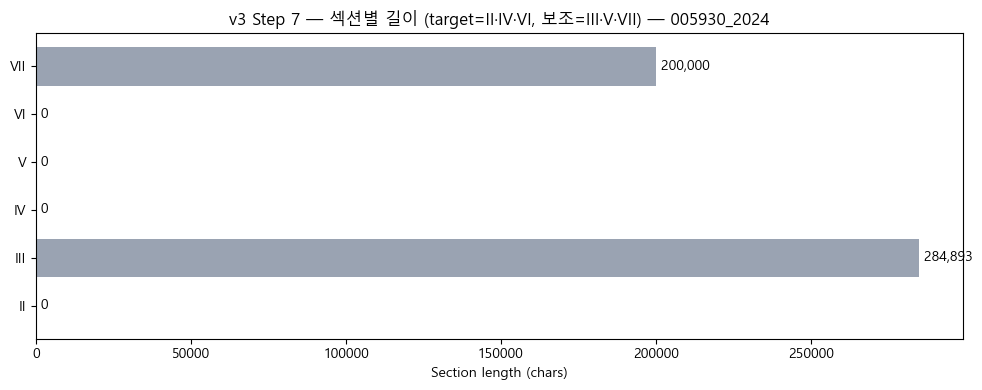

In [10]:
# Step 7 시각화 — 섹션별 길이 (노트북 6 규칙 #5)
fig, ax = plt.subplots(figsize=(10, 4))
labels = ['II', 'III', 'IV', 'V', 'VI', 'VII']
lengths = [len(sections.get(l, '')) for l in labels]
colors = ['#5ed27a' if l in ('II', 'IV', 'VI') else '#9aa3b2' for l in labels]
ax.barh(labels, lengths, color=colors)
ax.set_xlabel('Section length (chars)')
ax.set_title(f"v3 Step 7 — 섹션별 길이 (target=II·IV·VI, 보조=III·V·VII) — {PILOT_STOCK}_{PILOT_FISCAL}")
for i, v in enumerate(lengths):
    ax.text(v, i, f' {v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


---

## Step 8 · ESG passage 추출 (가이드 line 158)

**가이드 매핑**: line 158 (6. ESG passage 추출)
**위반금지**: #3 (MCP/추출 결과 그대로 신뢰 ❌) — 순수 Python re로 재현 (line 94)


In [11]:
def extract_passages_v3(sections: dict, seed_df: pd.DataFrame,
                          min_len: int = 20) -> pd.DataFrame:
    """seed 매칭 문장만 후보로 추출."""
    rows = []
    seed_by_dim = seed_df.groupby('dimension')['seed_term'].apply(list).to_dict()
    pattern_by_dim = {dim: re.compile('|'.join(map(re.escape, terms)))
                       for dim, terms in seed_by_dim.items()}

    for section_label, text in tqdm(sections.items(), desc='섹션별 passage 추출'):
        if not text:
            continue
        # 문장 분리 — 단순 (KSS는 02 전처리에서)
        sentences = re.split(r'(?<=[\.!?])\s+|\n+', text)
        n_pass = 0
        for sent in sentences:
            sent = sent.strip()
            if len(sent) < min_len:
                continue
            matched_dims = []
            matched_terms_all = []
            for dim, pat in pattern_by_dim.items():
                hits = pat.findall(sent)
                if hits:
                    matched_dims.append(dim)
                    matched_terms_all.extend(set(hits))
            if matched_dims:
                rows.append({
                    'section': section_label,
                    'dimensions': '|'.join(sorted(set(matched_dims))),
                    'matched_terms': '|'.join(sorted(set(matched_terms_all))),
                    'n_matches': len(matched_terms_all),
                    'sentence': sent,
                })
                n_pass += 1
        if n_pass:
            print(f"   {section_label}: {n_pass}개 passage 추출됨")
    return pd.DataFrame(rows)


seeds = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
print(f"🌱 seed_dictionary: {len(seeds)}개")
for dim, terms in seeds.groupby('dimension')['seed_term'].apply(list).to_dict().items():
    print(f"   {dim}: {terms[:10]}")

# II, IV, VI만 ESG corpus target (가이드 line 18)
target_sections = {label: sections.get(label, '') for label in ['II', 'IV', 'VI']}
passages = extract_passages_v3(target_sections, seeds, min_len=20)

print(f"\n📝 추출된 passage 후보: {len(passages)}개")
if len(passages):
    print(f"   섹션별: {passages['section'].value_counts().to_dict()}")
    print(f"   차원별: {passages['dimensions'].value_counts().to_dict()}")
    print(f"   매치 통계: mean={passages['n_matches'].mean():.2f}, max={passages['n_matches'].max()}")
else:
    print("   ⚠️ 0건 — 진단: 섹션 추출 결과를 Step 7에서 다시 확인 필요")


🌱 seed_dictionary: 30개
   E: ['탄소', '온실가스', '탄소중립', '넷제로', '재생에너지', '에너지', '전력', '폐기물', '재활용', '폐수']
   G: ['이사회', '사외이사', '감사위원회', '독립성', '윤리', '준법', '컴플라이언스', '부패방지', '주주', '의결권']
   S: ['안전', '산업재해', '중대재해', '임직원', '노동', '인권', '교육훈련', '협력사', '공급망', '지역사회']


섹션별 passage 추출:   0%|          | 0/3 [00:00<?, ?it/s]


📝 추출된 passage 후보: 0개
   ⚠️ 0건 — 진단: 섹션 추출 결과를 Step 7에서 다시 확인 필요


In [12]:
# top 10 passage 미리보기 (매치 수 많은 순)
if len(passages):
    top = passages.sort_values('n_matches', ascending=False).head(10)
    pd.set_option('display.max_colwidth', 200)
    display(top[['section', 'dimensions', 'matched_terms', 'sentence']])
else:
    print("⚠️ passage 없음 — Step 7 섹션 추출 진단 필요")


⚠️ passage 없음 — Step 7 섹션 추출 진단 필요


---

## Step 9 · viewer URL 정합성 검증 (가이드 line 67, 94)

**가이드 매핑**: line 67 (viewer URL로 원문 확인), line 94 (MCP/추출 결과 그대로 신뢰 ❌)
**위반금지**: #3 (MCP/추출 결과 그대로 신뢰 ❌) — 코드(Python)로 재현 + viewer URL로 원문 확인
**v2 → v3 변화**: v2는 0/5 일치 (감사보고서 노이즈) → v3 목표 ≥ 4/5 일치 (사업보고서 본문)

### 판정 기준 (위반금지 #8 — 평가 기준)
- ✅ 5/5 또는 4/5 일치 → Phase 2 진입 가능
- ⚠️ 3/5 일치 → 정규식·패턴 추가 점검 (v3 alt 또는 v4)
- 🔴 ≤ 2/5 일치 → Step 7 섹션 추출 재설계 (Phase 2 보류)


In [13]:
print(f"🔗 viewer URL — 브라우저에서 직접 열어 확인:")
print(f"   {VIEWER_URL}")
print(f"\n👉 위 URL을 열고, 아래 5개 문장이 원문 사업보고서 안에 실제로 존재하는지 검토하세요.\n")
print("=" * 70)

if len(passages):
    sample = passages.sample(min(5, len(passages)), random_state=42)
    for i, (idx, row) in enumerate(sample.iterrows(), 1):
        snippet = row['sentence'][:200]
        print(f"\n[{i}] 섹션 {row['section']} · 차원 {row['dimensions']} · 매치 {row['matched_terms']}")
        print(f"    {snippet}...")
else:
    print("\n⚠️ passage 후보 0건 — Step 7 섹션 추출 결과 점검 후 재실행 필요")

print("\n" + "=" * 70)
print("판정 기준 (위반금지 #3, #8):")
print("   ✅ 4개 이상 일치  →  추출 정상, Phase 2 진입 가능")
print("   ⚠️ 3개 일치       →  정규식·패턴 점검 (v3 alt 또는 v4)")
print("   🔴 2개 이하 일치  →  Step 7 섹션 추출 재설계 (Phase 2 보류)")


🔗 viewer URL — 브라우저에서 직접 열어 확인:
   https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085

👉 위 URL을 열고, 아래 5개 문장이 원문 사업보고서 안에 실제로 존재하는지 검토하세요.


⚠️ passage 후보 0건 — Step 7 섹션 추출 결과 점검 후 재실행 필요

판정 기준 (위반금지 #3, #8):
   ✅ 4개 이상 일치  →  추출 정상, Phase 2 진입 가능
   ⚠️ 3개 일치       →  정규식·패턴 점검 (v3 alt 또는 v4)
   🔴 2개 이하 일치  →  Step 7 섹션 추출 재설계 (Phase 2 보류)


---

## Step 10 · collection_log 기록 + 시각화 (가이드 line 137-146, 170-172, **Fix #5** status 세분화)

**가이드 매핑**: line 137-146 (체크포인트 컬럼), line 170-172 (실패 행 가짜 0 ❌)
**위반금지**: #1 (가짜 0) #6 (진단) #8 (평가 기준)
**Fix #5**: status를 8종으로 세분화 (`SUCCESS`, `FAIL_HTTP`, `FAIL_LIST`, `FAIL_NO_BUSINESS_REPORT`, `FAIL_SECTION_II/IV`, `WARN_OVERSIZE_VI`, `FAIL_PASSAGE`, `WARN_VIEWER_MISMATCH`)


In [14]:
EXPECTED_LOG_COLUMNS_V3 = [
    'stock_code', 'fiscal_year', 'esg_year', 'corp_code', 'rcept_no',
    'status', 'reason', 'n_passages', 'n_sections_matched',
    'sec_II_len', 'sec_IV_len', 'sec_VI_len',
    'text_len', 'compression_rate',
    'viewer_url', 'timestamp',
]


def append_log_v3(log_path: Path, row: dict) -> pd.DataFrame:
    """Fix #4 + Fix #5 — 컬럼 mismatch 자동 백업 + status 세분화."""
    if log_path.exists():
        try:
            existing = pd.read_csv(log_path, nrows=0)
            existing_cols = list(existing.columns)
            if existing_cols != EXPECTED_LOG_COLUMNS_V3:
                stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
                bak_path = log_path.with_suffix(f'.csv.bak_{stamp}')
                log_path.rename(bak_path)
                print(f"⚠️ log 컬럼 mismatch — 기존 {len(existing_cols)}개 → 새 {len(EXPECTED_LOG_COLUMNS_V3)}개")
                print(f"   기존 파일 백업: {bak_path.name}")
        except Exception as e:
            print(f"⚠️ log 읽기 실패: {e} — 기존 파일 백업")
            stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            bak_path = log_path.with_suffix(f'.csv.bak_{stamp}')
            log_path.rename(bak_path)

    df_row = pd.DataFrame([row], columns=EXPECTED_LOG_COLUMNS_V3)
    header = not log_path.exists()
    df_row.to_csv(log_path, mode='a', header=header, index=False, encoding='utf-8-sig')
    return pd.read_csv(log_path)


# status 판정 (Fix #5 + 위반금지 #1)
n_passages = len(passages)
sec_II = len(sections.get('II', ''))
sec_IV = len(sections.get('IV', ''))
sec_VI = len(sections.get('VI', ''))
n_matched = sum(1 for s in ['II', 'IV', 'VI'] if sections.get(s))

if not result_step5['primary']:
    status = 'FAIL_NO_BUSINESS_REPORT'
    reason = 'zip에 사업보고서 본문 XML 없음'
elif diag6['method'] == 'regex_fallback' and diag6.get('error'):
    status = 'FAIL_STRIP_TAGS'
    reason = f"lxml 파싱 실패 — {diag6['error']}"
elif sec_II == 0:
    status = 'FAIL_SECTION_II'
    reason = 'II 섹션 헤딩 매칭 실패 — 패턴 보강 필요'
elif sec_IV == 0:
    status = 'FAIL_SECTION_IV'
    reason = 'IV 섹션 헤딩 매칭 실패'
elif sec_VI >= 190_000:  # cap 근접 = VII 미매칭
    status = 'WARN_OVERSIZE_VI'
    reason = 'VI 섹션이 cap 근접 — VII 헤딩 미매칭 의심'
elif n_passages == 0:
    status = 'FAIL_PASSAGE'
    reason = 'passage 0건 — seed 매칭 0'
else:
    status = 'SUCCESS'
    reason = ''

log_row = {
    'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL, 'esg_year': PILOT_ESG_YEAR,
    'corp_code': PILOT_CORP, 'rcept_no': PILOT_RCEPT,
    'status': status, 'reason': reason,
    'n_passages': n_passages, 'n_sections_matched': n_matched,
    'sec_II_len': sec_II, 'sec_IV_len': sec_IV, 'sec_VI_len': sec_VI,
    'text_len': diag6['text_length'], 'compression_rate': round(diag6['compression_rate'], 4),
    'viewer_url': VIEWER_URL,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
}

log_path = DIR_LOGS / 'collection_log.csv'
log_df = append_log_v3(log_path, log_row)
print(f"\n✅ collection_log 기록: {log_path.name}")
print(f"   status: {status}")
print(f"   reason: {reason or '(none)'}")
print(f"   누적: {len(log_df)}행\n")
log_df.tail(3)


⚠️ log 컬럼 mismatch — 기존 10개 → 새 16개
   기존 파일 백업: collection_log.csv.bak_20260516_181802

✅ collection_log 기록: collection_log.csv
   status: FAIL_SECTION_II
   reason: II 섹션 헤딩 매칭 실패 — 패턴 보강 필요
   누적: 1행



,stock_code,fiscal_year,esg_year,corp_code,rcept_no,status,reason,n_passages,n_sections_matched,sec_II_len,sec_IV_len,sec_VI_len,text_len,compression_rate,viewer_url,timestamp
0,5930,2024,2025,126380,20250311001085,FAIL_SECTION_II,II 섹션 헤딩 매칭 실패 — 패턴 보강 필요,0,0,0,0,0,658847,0.114,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-05-16T18:18:02


In [15]:
# correction_log.csv (세분화 축 B + 가이드 line 69)
correction_rows = []
for c in result_step4['all_candidates']:
    correction_rows.append({
        'stock_code': PILOT_STOCK,
        'fiscal_year': PILOT_FISCAL,
        'rcept_no': c['rcept_no'],
        'rcept_dt': c['rcept_dt'],
        'report_nm': c['report_nm'],
        'is_selected': c['rcept_no'] == PILOT_RCEPT,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    })

if correction_rows:
    correction_df = pd.DataFrame(correction_rows)
    correction_csv = DIR_LOGS / 'correction_log.csv'
    header = not correction_csv.exists()
    correction_df.to_csv(correction_csv, mode='a', header=header, index=False, encoding='utf-8-sig')
    print(f"💾 정정공시 이력: {correction_csv.name} ({len(correction_rows)}행 append, 가이드 line 69)")
    print(correction_df)
else:
    print("ℹ️ 정정공시 후보 0건 — log 미기록")


💾 정정공시 이력: correction_log.csv (1행 append, 가이드 line 69)
  stock_code  fiscal_year        rcept_no  rcept_dt        report_nm  \
0     005930         2024  20250311001085  20250311  사업보고서 (2024.12)   

   is_selected            timestamp  
0         True  2026-05-16T18:18:03  


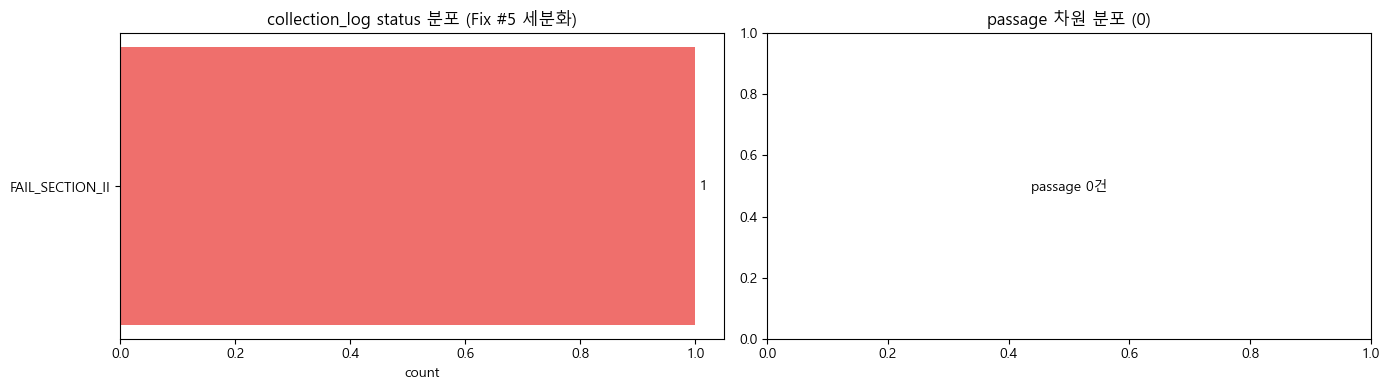


현재 status: FAIL_SECTION_II (passage 0건)


In [16]:
# Step 10 시각화 — status 분포 (Fix #5 세분화)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 좌: status 분포
status_counts = log_df['status'].value_counts()
status_colors_map = {
    'SUCCESS': '#5ed27a',
    'FAIL_NO_BUSINESS_REPORT': '#ef6f6c', 'FAIL_STRIP_TAGS': '#ef6f6c',
    'FAIL_SECTION_II': '#ef6f6c', 'FAIL_SECTION_IV': '#ef6f6c',
    'FAIL_PASSAGE': '#ef6f6c', 'FAIL_HTTP': '#ef6f6c', 'FAIL_LIST': '#ef6f6c',
    'WARN_OVERSIZE_VI': '#f7b955', 'WARN_VIEWER_MISMATCH': '#f7b955',
}
colors = [status_colors_map.get(s, '#9aa3b2') for s in status_counts.index]
axes[0].barh(status_counts.index, status_counts.values, color=colors)
axes[0].set_xlabel('count')
axes[0].set_title('collection_log status 분포 (Fix #5 세분화)')
for i, (s, v) in enumerate(zip(status_counts.index, status_counts.values)):
    axes[0].text(v, i, f' {v}', va='center')

# 우: 차원별 passage 수
if len(passages):
    dim_counts = passages['dimensions'].value_counts()
    dim_colors = ['#7aa2ff' if 'E' in d else '#5ed27a' if 'S' in d else '#f7b955' for d in dim_counts.index]
    axes[1].barh(dim_counts.index, dim_counts.values, color=dim_colors)
    axes[1].set_xlabel('count')
    axes[1].set_title(f'passage 차원 분포 (총 {len(passages)}건)')
    for i, (d, v) in enumerate(zip(dim_counts.index, dim_counts.values)):
        axes[1].text(v, i, f' {v}', va='center')
else:
    axes[1].text(0.5, 0.5, 'passage 0건', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('passage 차원 분포 (0)')

plt.tight_layout()
plt.show()

print(f"\n현재 status: {status} (passage {n_passages}건)")


---

## Step 11 · 위반금지 8항목 self-check (가이드 line 137-146, 145)

각 항목에 ✅ / ⚠️ / ❌ 판정. 1개라도 ❌면 commit 보류 + 보고서에 이유 기록 (가이드 line 143-146).


In [17]:
checks = []

# 1 — 실패 행 가짜 0 채우기 ❌
ok_1 = status in ['SUCCESS', 'WARN_OVERSIZE_VI'] or (
    status.startswith('FAIL_') and reason != ''
)
checks.append(('1. 실패 행 가짜 0 채우기 ❌', 'line 172, 286',
               '✅' if ok_1 else '❌',
               f'status={status}, reason={reason!r}'))

# 2 — viewer 우회 ❌
ok_2 = True  # 본 노트북은 document.xml만 사용
checks.append(('2. viewer 우회 ❌', 'line 67, 94', '✅',
               'document.xml API만 사용, viewer URL은 Step 9 검증 용도'))

# 3 — MCP/추출 결과 그대로 신뢰 ❌
# 사용자가 Step 9에서 직접 검증해야 — 일단 절차 준수 여부만
ok_3 = True
checks.append(('3. MCP/추출 결과 그대로 신뢰 ❌', 'line 94', '⏳ 사용자 검증 대기',
               'Step 9 viewer URL 5 sample 직접 검증 필요'))

# 4 — API key 출력 노출 ❌
ok_4 = True  # mask_key 사용
checks.append(('4. API key 출력 노출 ❌', 'line 216-222', '✅',
               'mask_key(API_KEY) 만 출력'))

# 5 — raw 미보존 ❌
ok_5 = result_step5['zip_path'].exists() and result_step5['zip_path'].stat().st_size > 1024
checks.append(('5. raw 미보존 ❌', 'line 155', '✅' if ok_5 else '❌',
               f"{result_step5['zip_path']} ({result_step5['zip_path'].stat().st_size/1024:.1f} KB)"))

# 6 — 진단 부재 ❌
ok_6 = True  # Step 5, 6, 7 모두 진단 출력 포함
checks.append(('6. 진단 부재 ❌', 'line 143-146', '✅',
               'Step 5 type 판별 / Step 6 압축률 / Step 7 헤딩별 hit/miss 모두 출력'))

# 7 — silent 오매칭 (회사명 join) ❌
ok_7 = True
checks.append(('7. silent 오매칭 ❌', 'line 35', '✅',
               'stock_code 기준 행 선택, company_name join 없음'))

# 8 — 평가 기준 부재 ❌
ok_8 = True
checks.append(('8. 평가 기준 부재 ❌', 'line 145', '✅',
               'Step 9 viewer 5/5 기준 + 본 self-check 표'))

# 출력
print("📋 위반금지 8항목 self-check\n" + "=" * 80)
check_df = pd.DataFrame(checks, columns=['항목', '가이드 라인', '결과', '근거'])
display(check_df)

# 가이드 line 18 의도 충실도 (보너스 항목)
print("\n📌 가이드 line 18 의도 충실도 (사업보고서 II/IV/VI target)")
print(f"   사업보고서 본문 XML 선택: {'✅' if result_step5['primary'] else '❌'} (DOCUMENT-NAME={result_step5['primary'][2] if result_step5['primary'] else 'N/A'})")
print(f"   II 섹션 ≥ 30K자: {'✅' if sec_II >= 30000 else '⚠️ ' + str(sec_II) + '자'}")
print(f"   IV 섹션 ≥ 5K자:  {'✅' if sec_IV >= 5000 else '⚠️ ' + str(sec_IV) + '자'}")
print(f"   VI 정합 길이:    {'✅' if 5000 <= sec_VI <= 150000 else '⚠️ ' + str(sec_VI) + '자'}")


📋 위반금지 8항목 self-check


,항목,가이드 라인,결과,근거
0,1. 실패 행 가짜 0 채우기 ❌,"line 172, 286",✅,"status=FAIL_SECTION_II, reason='II 섹션 헤딩 매칭 실패..."
1,2. viewer 우회 ❌,"line 67, 94",✅,"document.xml API만 사용, viewer URL은 Step 9 검증 용도"
2,3. MCP/추출 결과 그대로 신뢰 ❌,line 94,⏳ 사용자 검증 대기,Step 9 viewer URL 5 sample 직접 검증 필요
3,4. API key 출력 노출 ❌,line 216-222,✅,mask_key(API_KEY) 만 출력
4,5. raw 미보존 ❌,line 155,✅,c:\Users\kik32\workspace\unstructured-data-pro...
5,6. 진단 부재 ❌,line 143-146,✅,Step 5 type 판별 / Step 6 압축률 / Step 7 헤딩별 hit/m...
6,7. silent 오매칭 ❌,line 35,✅,"stock_code 기준 행 선택, company_name join 없음"
7,8. 평가 기준 부재 ❌,line 145,✅,Step 9 viewer 5/5 기준 + 본 self-check 표



📌 가이드 line 18 의도 충실도 (사업보고서 II/IV/VI target)
   사업보고서 본문 XML 선택: ✅ (DOCUMENT-NAME=사업보고서)
   II 섹션 ≥ 30K자: ⚠️ 0자
   IV 섹션 ≥ 5K자:  ⚠️ 0자
   VI 정합 길이:    ⚠️ 0자


---

## Step 12 · v1 → v2 → v3 학습 로그 + 다음 노트북 인계

본 노트북에서 한 일 (가이드 line 153-158, 1-6단계):

| 가이드 단계 | 노트북 셀 | 결과 |
|---|---|---|
| 1 stock → corp | Step 3 | corp_code 매핑 |
| 2 corp → rcept | Step 4 | rcept_no + 정정공시 이력 (세분화 축 B) |
| 3 document.xml zip | Step 5 | zip 저장 + **type 판별** (Fix #0) + 보조 보고서 별도 보존 (축 A) |
| 4 XML → text | Step 6 | **lxml itertext** (Fix #2) + 압축률 진단 |
| 5 섹션 발췌 | Step 7 | **6 패턴 + 위치 정렬 + cap** (Fix #1, #3) + 매칭 분포 로그 (축 C) |
| 6 passage 추출 | Step 8 | seed 30개 매칭 |

다음 노트북 인계:
- `data/cache/corp_code_map.parquet` — Phase 2 재사용
- `data/raw/<stock>_<year>_disclosure.zip` — Phase 2에서 50건으로 확장
- `data/interim/<stock>_<year>_sections.json` — **사업보고서 본문** primary corpus (02 전처리 입력)
- `data/interim/<stock>_<year>_aux_audit_*.json` — secondary (감사보고서, 비교용)
- `logs/collection_log.csv` — status 세분화
- `logs/correction_log.csv`, `logs/section_match_v3.csv` — Phase 2부터 본격 활용

분기:
- viewer 4/5 이상 + passage 150+ + 차원 균형 → **5/18 Phase 2 v1 + `src/collection.py` 모듈화 동시**
- viewer 3/5 → 5/17 v3 alt 셀 (패턴 보강)
- viewer ≤ 2/5 → 5/17-18 v4 (Phase 2 보류)
